# 实验十九：图像表示与描述——傅里叶描述子

**实验目的：**
掌握对目标边界进行数值化描述的方法，理解如何利用一维傅里叶变换提取二维形状的全局与局部特征。

### 💡 实际应用场景说明
在计算机视觉中，认出一个物体的轮廓往往比认出它的颜色更重要。傅里叶描述子在以下工业和科研场景中大放异彩：
1. **军工与航空航天：** 飞机/舰船轮廓识别。即使侦察机拍到的敌方战机发生了旋转或缩放，通过提取其轮廓的傅里叶描述子（具有平移、旋转、缩放不变性），也能与数据库中的模型进行精确匹配。
2. **植物学与农业：** 树叶形状分类。自然界中同一品种的树叶大小各异，但它们的“基本形状特征（低频分量）”和“边缘锯齿特征（高频分量）”在频域中具有高度的一致性。
3. **OCR (光学字符识别)：** 极简的字体识别。字母“A”和字母“B”的外部轮廓在傅里叶频域中的低频系数有着天壤之别。


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(18, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        # 处理单通道灰度图或二值图
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 1. 自动生成测试目标：不规则的“海星”或“树叶”形状
为了让傅里叶描述子的效果最明显，我们需要一个既有**清晰主干轮廓（低频）**，又有**复杂边缘尖刺（高频）**的图案。


✅ 成功生成带有多层频率特征的测试图案！


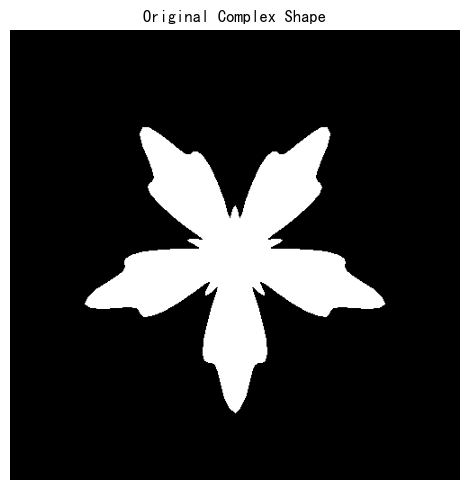

In [24]:
# 创建一张黑底图像
img_shape = np.zeros((500, 500), dtype=np.uint8)

# 用极坐标生成一个不规则的星形/树叶多边形
center = (250, 250)
points = []
# 遍历 360 度，加入基础半径和多个正弦波形的叠加（模拟高频的尖刺和低频的起伏）
for angle in range(0, 360, 2):
    theta = np.radians(angle)
    # 基础半径 100 + 低频起伏 60*sin(5*theta) + 高频尖刺 15*cos(20*theta)
    r = 100 + 60 * np.sin(5 * theta) + 15 * np.cos(20 * theta) 
    x = int(center[0] + r * np.cos(theta))
    y = int(center[1] + r * np.sin(theta))
    points.append([x, y])

pts = np.array(points, np.int32).reshape((-1, 1, 2))
# 填充多边形为白色
cv2.fillPoly(img_shape, [pts], 255)

print("✅ 成功生成带有多层频率特征的测试图案！")
show_images([img_shape], ["Original Complex Shape"], figsize=(5, 5))


## 2. 边界提取与复数序列转换
**核心数学思想：** 提取物体的边界后，我们会得到一系列顺时针排列的坐标点 $(x_k, y_k)$。
我们将二维平面的 x 轴视为实轴，y 轴视为虚轴，从而把每一个二维坐标点变成一个一维的复数：
$$s(k) = x_k + j y_k$$
这样一来，复杂的二维轮廓跟踪问题，就变成了一段普通的一维复数信号处理问题！


提取了 1544 个边界点，并已成功转换为复数序列。


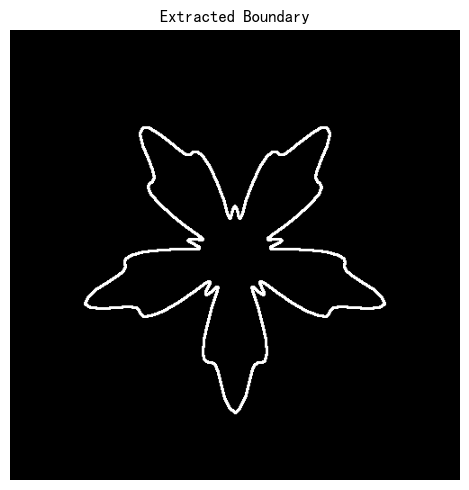

In [25]:
# 1. 提取图像轮廓 (只取最外侧轮廓 RETR_EXTERNAL)
contours, _ = cv2.findContours(img_shape, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
contour = contours[0] # 获取最大轮廓

# 将轮廓画出来验证一下
img_contour = np.zeros_like(img_shape)
cv2.drawContours(img_contour, [contour], -1, 255, 2)

# 2. 将轮廓坐标转换为 1 维复数序列
# contour 的形状是 (N, 1, 2)，N是边界像素点的总数
contour_squeeze = contour.squeeze() 
# 取出 X 坐标作为实部，Y 坐标作为虚部，构造复数数组
complex_contour = contour_squeeze[:, 0] + 1j * contour_squeeze[:, 1]

print(f"提取了 {len(complex_contour)} 个边界点，并已成功转换为复数序列。")
show_images([img_contour], ["Extracted Boundary"], figsize=(5, 5))


## 3. 傅里叶描述子 (Fourier Descriptors) 的计算与截断
对复数序列 $s(k)$ 进行一维离散傅里叶变换（1D-DFT），得到的频域系数就是**傅里叶描述子**。
* **第 0 项（直流分量 / 直流系数）：** 代表了物体质心的位置。
* **低频系数：** 决定了物体整体的、宏观的基础形状（比如大致是一个圆还是一个椭圆）。
* **高频系数：** 决定了物体边缘的微小细节（比如尖角、毛刺）。

我们在频域中强制将不同比例的高频系数置为 0，然后逆变换重建形状，来看看会发生什么！


 从低频到高频的细节雕刻


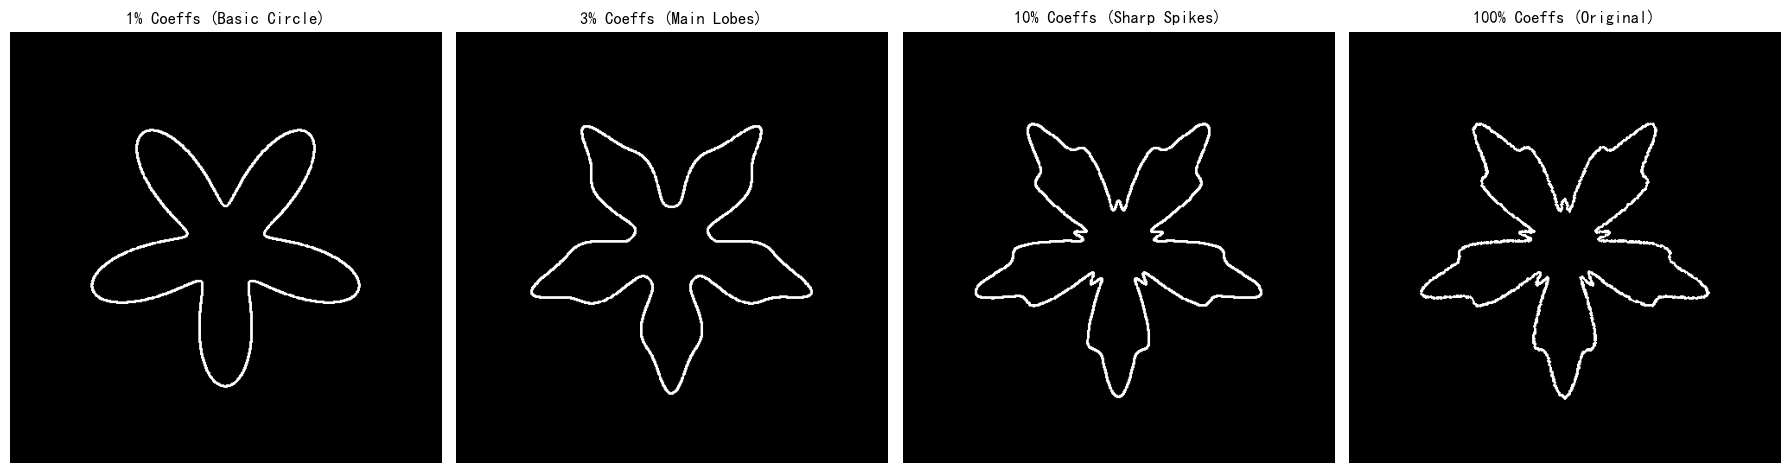

In [26]:
# 1. 进行一维傅里叶变换
fd = np.fft.fft(complex_contour)

# 为了方便截断高频，我们将低频分量移到数组的中心
fd_shifted = np.fft.fftshift(fd)

# 辅助函数：根据保留比例重建形状
def reconstruct_shape(fd_shift_array, retain_ratio):
    total_points = len(fd_shift_array)
    # 计算需要保留的中心低频点数
    retain_count = int(total_points * retain_ratio)

    # 创建一个全 0 的数组
    fd_filtered = np.zeros_like(fd_shift_array)

    # 找到中心的起始和结束索引，将中心的低频数据复制过去，其余两端（高频）保持为0
    start_idx = total_points // 2 - retain_count // 2
    end_idx = start_idx + retain_count

    if retain_count > 0:
        fd_filtered[start_idx:end_idx] = fd_shift_array[start_idx:end_idx]

    # 逆平移，然后进行一维逆傅里叶变换
    fd_ishift = np.fft.ifftshift(fd_filtered)
    reconstructed_complex = np.fft.ifft(fd_ishift)

    # 提取实部作为 X 坐标，虚部作为 Y 坐标
    x_recon = np.real(reconstructed_complex)
    y_recon = np.imag(reconstructed_complex)

    # 将坐标点重新画在空白图上
    recon_img = np.zeros((500, 500), dtype=np.uint8)
    pts_recon = np.column_stack((x_recon, y_recon)).astype(np.int32)
    cv2.polylines(recon_img, [pts_recon], isClosed=True, color=255, thickness=2)

    return recon_img

# ==========================================
# 分别保留 1%, 3%, 10%, 100% 的傅里叶描述子进行重建
# ==========================================
img_1_percent = reconstruct_shape(fd_shifted, 0.01)  # 只用 1% 的数据！
img_3_percent = reconstruct_shape(fd_shifted, 0.03)  # 只用 3% 的数据
img_10_percent = reconstruct_shape(fd_shifted, 0.10) # 保留 10%
img_100_percent = reconstruct_shape(fd_shifted, 1.0) # 保留所有特征

print(" 从低频到高频的细节雕刻")
show_images([img_1_percent, img_3_percent, img_10_percent, img_100_percent], 
            ["1% Coeffs (Basic Circle)", 
             "3% Coeffs (Main Lobes)", 
             "10% Coeffs (Sharp Spikes)", 
             "100% Coeffs (Original)"])


## 4. 实验现象深度解析
当你在课堂上运行这段代码时，你会看到极其震撼的一幕：
1. **只保留 1% 系数：** 重建的形状退化成了一个极其光滑的圆形/椭圆形。这说明最核心的极少数低频分量，只记录了物体最宏观的“轮廓骨架”。
2. **保留 3% 系数：** 开始出现 5 个大的波浪起伏。这就是我们在生成形状时加入的 `60*sin(5*theta)` 特征，它代表了物体的次级结构。
3. **保留 10% 系数：** 形状几乎已经和原图一模一样，边缘极其锋利的“锯齿”已经完全复原。这说明物体的形状信息存在**极大的冗余**。

**💡 工业级总结：**
我们根本不需要几千个边缘像素点 $(x, y)$ 来描述这片树叶。在实际的模型识别库中，我们只需要存储它**最核心的前几十个傅里叶描述子**，就足以完美区分一架波音 747 和一架 F-22 战斗机。这就是数学带来的极致压缩与优雅！
